# Code for Processing Radio Data
(Ishfahani Rusyda, u7762747)\
This repository contains code used to process and analyze radio astronomy data.

### Exercise 1

This section addresses Exercise 1. The tasks include:
- Plotting the radio data and the fitted line
- Performing integration
- Calculating the total flux
- Estimating the energy

### Exercise 2

This section addresses Exercise 2, focusing on a different set of analysis steps as defined in the corresponding question.


## Exercise 1
The writeup of this section is written in pdf.

Line 1 (log-log): log(y) = 0.52log(x) + 2.25
Line 2 (log-log): log(y) = 0.71log(x) + 2.78
Line 3 (log-log): log(y) = -0.78log(x) + 2.78

Piecewise function for n(S) in sr^{-1}Jy^{-1} (log-log scale):
S^2.5n(S) = 1.76e+02 + S^0.52 , for 3.00e-04 <= S <= 1.50e-03
S^2.5n(S) = 6.00e+02 + S^0.71, for 1.50e-03 <= S <= 1.00e+00
S^2.5n(S) = 6.00e+02 + S^-0.78, for 1.00e+00 <= S <= 1.00e+01


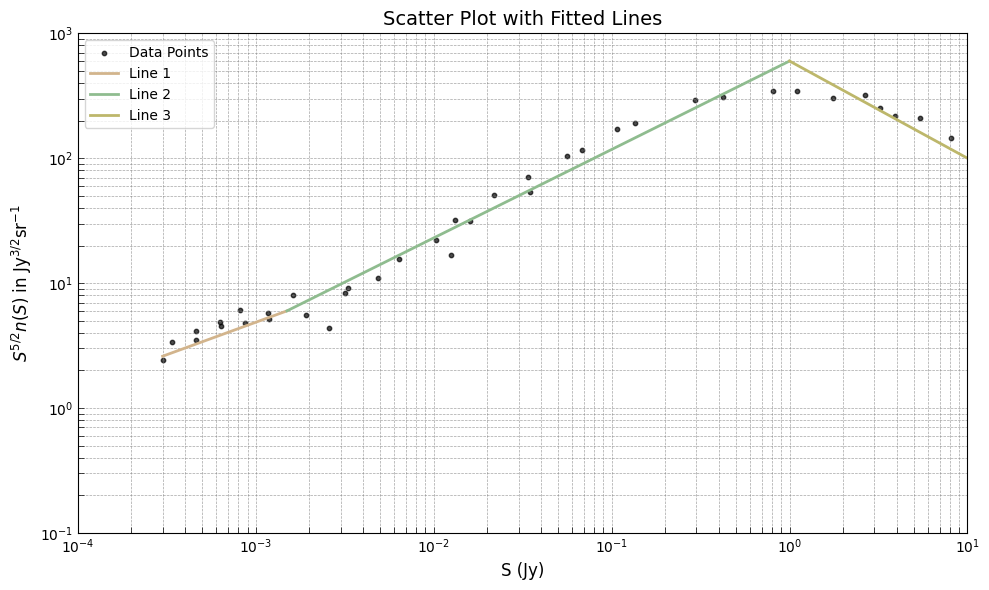

In [1]:
file = 'nvss.csv'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.fft import fft, fftshift, ifft, ifftshift, fftfreq


# Read the CSV file
df = pd.read_csv(file)

# Plot the dataset
plt.figure(figsize=(10, 6))
plt.scatter(df['y'], df['x'], label='Data Points', color='black', alpha=0.7, s=10)  # Adjusted color, transparency, and size

# Add three straight lines with matching colors
# Line 1
x1 = [3e-4, 1.5e-3]  # Adjust x points
y1 = [2.6e0, 6e0]    # Adjust y points
plt.plot(x1, y1, label='Line 1', color='tan', linewidth=2)

# Line 2
x2 = [1.5e-3, 1e0]   # Adjust x points
y2 = [6e0, 6e2]      # Adjust y points
plt.plot(x2, y2, label='Line 2', color='darkseagreen', linewidth=2)

# Line 3
x3 = [1e0, 1e1]      # Adjust x points
y3 = [6e2, 1e2]      # Adjust y points
plt.plot(x3, y3, label='Line 3', color='darkkhaki', linewidth=2)

# Calculate and print the linear equations for the three lines in log-log scale
def calculate_log_linear_equation(x, y):
    log_x = np.log10(x)
    log_y = np.log10(y)
    slope = (log_y[1] - log_y[0]) / (log_x[1] - log_x[0])
    intercept = log_y[0] - slope * log_x[0]
    return slope, intercept

slope1, intercept1 = calculate_log_linear_equation(x1, y1)
slope2, intercept2 = calculate_log_linear_equation(x2, y2)
slope3, intercept3 = calculate_log_linear_equation(x3, y3)

print(f"Line 1 (log-log): log(y) = {slope1:.2f}log(x) + {intercept1:.2f}")
print(f"Line 2 (log-log): log(y) = {slope2:.2f}log(x) + {intercept2:.2f}")
print(f"Line 3 (log-log): log(y) = {slope3:.2f}log(x) + {intercept3:.2f}")

# Estimate the amplitude for each segment in log-log scale
amplitude1 = 10**intercept1
amplitude2 = 10**intercept2
amplitude3 = 10**intercept3

# Print the piecewise function for n(S) in log-log scale
print("\nPiecewise function for n(S) in sr^{-1}Jy^{-1} (log-log scale):")
print(f"S^{5/2}n(S) = {amplitude1:.2e} + S^{slope1:.2f} , for {x1[0]:.2e} <= S <= {x1[1]:.2e}")
print(f"S^{5/2}n(S) = {amplitude2:.2e} + S^{slope2:.2f}, for {x2[0]:.2e} <= S <= {x2[1]:.2e}")
print(f"S^{5/2}n(S) = {amplitude3:.2e} + S^{slope3:.2f}, for {x3[0]:.2e} <= S <= {x3[1]:.2e}")

# Set axis limits
plt.ylim(0.1, 1000)
plt.xscale('log')
plt.yscale('log')
plt.xlim(10**(-4), 10**(1))

# Add grid, legend, and show the plot
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7, which='both')  # Softer gridlines
plt.minorticks_on()  # Enable minor ticks for finer grid
plt.tick_params(axis='both', which='both', direction='in', length=4, width=0.5)

# Add legend and labels
plt.legend()
plt.title("Scatter Plot with Fitted Lines", color='black', fontsize=14)
plt.xlabel("S (Jy)", color='black', fontsize=12)
plt.ylabel(r"$S^{5/2}n(S)$ in $\mathrm{Jy}^{3/2}\mathrm{sr}^{-1}$", color='black', fontsize=12)
plt.tight_layout()
plt.show()

In [2]:
# Given piecewise function for S^{5/2}n(S)
segments_s5_2_n_s = [
    {"A": 1.76e+02, "m": 0.52, "S_min": 1e-04, "S_max": 1.50e-03},  # Segment 1
    {"A": 6.00e+02, "m": 0.71, "S_min": 1.50e-03, "S_max": 1.00e+00},  # Segment 2
    {"A": 6.00e+02, "m": -0.78, "S_min": 1.00e+00, "S_max": 1.00e+01}, # Segment 3
]

# Convert S^{5/2}n(S) to n(S)
segments_n_s = []
for segment in segments_s5_2_n_s:
    A_s5_2_n_s = segment["A"]
    m_s5_2_n_s = segment["m"]
    
    # For n(S), the amplitude and slope are adjusted as follows:
    A_n_s = A_s5_2_n_s  # Adjust amplitude
    m_n_s = m_s5_2_n_s - (5/2)  # Adjust slope
    
    # Store the converted segment
    segments_n_s.append({
        "A": A_n_s,
        "m": m_n_s,
        "S_min": segment["S_min"],
        "S_max": segment["S_max"]
    })

# Print the piecewise function for n(S)
print("Piecewise function for n(S) in sr^{-1}Jy^{-1} (log-log scale):")
for segment in segments_n_s:
    print(f"n(S) = {segment['A']:.2e} + S^{segment['m']:.2f}, for {segment['S_min']:.2e} <= S <= {segment['S_max']:.2e}")

Piecewise function for n(S) in sr^{-1}Jy^{-1} (log-log scale):
n(S) = 1.76e+02 + S^-1.98, for 1.00e-04 <= S <= 1.50e-03
n(S) = 6.00e+02 + S^-1.79, for 1.50e-03 <= S <= 1.00e+00
n(S) = 6.00e+02 + S^-3.28, for 1.00e+00 <= S <= 1.00e+01


In [3]:


# Define the piecewise power-law model for n(S)
def n_s(S, A, m):
    return A * S**m

# Define S * n(S) for integration
def s_n_s(S, A, m):
    return S * n_s(S, A, m)

# Parameters for each segment (from previous calculations)
segments = [
    {"A": 1.76e2, "m": -1.98, "S_min": 1e-4, "S_max": 1.5e-3},  # Segment 1
    {"A": 6.00e2, "m": -1.79, "S_min": 1.5e-3, "S_max": 1.0},  # Segment 2
    {"A": 6e2, "m": -3.28, "S_min": 1.0, "S_max": np.inf},     # Segment 3
]

# Integrate S * n(S) for each segment
total_flux = 0
for segment in segments:
    A = segment["A"]
    m = segment["m"]
    S_min = segment["S_min"]
    S_max = segment["S_max"]
    
    # Perform the integration
    flux, _ = quad(s_n_s, S_min, S_max, args=(A, m))
    print(flux)
    total_flux += flux

print(f"Total flux density per unit solid angle : {total_flux:.4e} sr^-1 Jy")

407.3646805128427
2127.834617751466
468.75000000000006
Total flux density per unit solid angle : 3.0039e+03 sr^-1 Jy


In [4]:
# Constants
F = 3004  # Total flux density in W m^-2 Hz^-1 sr^-1
Omega = 10.3  # Sky area in steradians
t = 30  # Observation duration in seconds (minimum)  # Observation duration in seconds (maximum)
Delta_nu = 100 * 10**6  # Bandwidth in Hz

# Free parameter: Collecting area of the telescope (e.g., VLA)
# For the VLA, 27 dishes with ~452 m^2 per dish
A = 28 * (25**2)  # Total collecting area in m^2

# Calculate total energy for both observation durations
E = 10**(-26)* F * (A) * t * (Delta_nu) * (Omega)

# Print results
print(f"Total energy imparted by extragalactic radio sources (30 s): {E:.4e} J")

Total energy imparted by extragalactic radio sources (30 s): 1.6244e-08 J


In [5]:
# Constants for the snowflake
mass_snowflake = 2.99e-6  # Mass in kg (2.99 mg)
velocity_snowflake = 1.5 * 0.44704  # Terminal velocity in m/s (1.5 mph to m/s)

# Calculate the kinetic energy of the snowflake
kinetic_energy_snowflake = 0.5 * mass_snowflake * velocity_snowflake**2
print(f"Kinetic energy of a falling snowflake: {kinetic_energy_snowflake:.4e} J")

# Compare the snowflake's energy with the NVSS energy
num_snowflakes_min = E / kinetic_energy_snowflake

print(f"Number of snowflakes needed to match NVSS energy (30 s): {num_snowflakes_min:.2e}")

Kinetic energy of a falling snowflake: 6.7223e-07 J
Number of snowflakes needed to match NVSS energy (30 s): 2.42e-02


# Exercise 2

## SETUP

This script wraps all steps into a single function, making it easy to adjust for specific cases by calling that function.

## Step 1: Define a 1D Array

I define a 1D array representing the sky (adjustable in length). Four test cases are implemented:
- Delta function
- Sine wave
- Gaussian
- Top-hat

## Step 2: Fourier Transform (FFT)

I use `scipy.fft` to compute the Fourier transform of the data. To center the zero-frequency component, we apply `fftshift`, resulting in frequency indices ranging from negative to positive.

- **Amplitude**: Obtained as the absolute value of the visibility (FFT output)
- **Phase**: Obtained using the angle of the visibility

All results are plotted as a function of the shifted frequency index.

**Debugging note**: To correctly display the full frequency range, we use  
`freqs = fftshift(fftfreq(N, d=1/N))`.

## Step 3: Weight Function

Several weighting schemes are implemented:
- Random weighting
- High or low-frequency cutoffs
- Middle-frequency selection
- Both high and low-frequency cutoffs

The weights are applied to the FFT-shifted visibility. To ensure symmetry, we visualize the weights.

To guarantee the inverse FFT results in a real-valued dirty image, we enforce symmetric weighting.

## Step 4: Adding noise and phase error

In addition to applying weights, I also introduce adjustable noise and phase error. These can be customized to simulate different observational conditions.

## Step 5: Observed Image

The dirty image is obtained via the inverse FFT. The synthesized beam is also plotted.


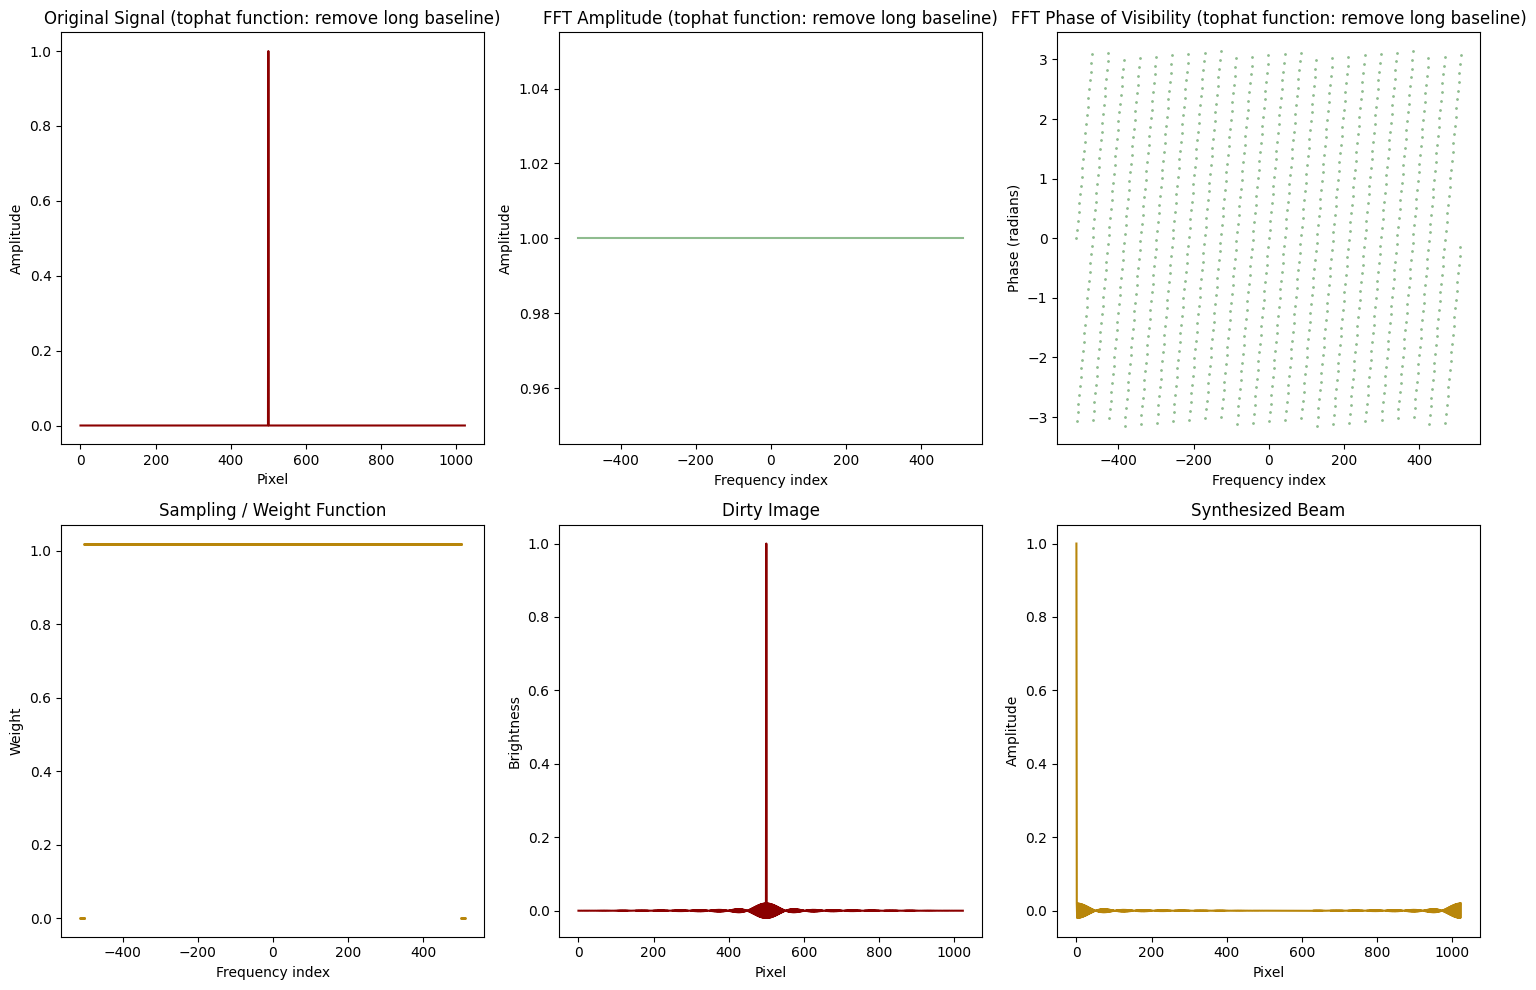

Peak amplitude of synthesized beam: 1.0


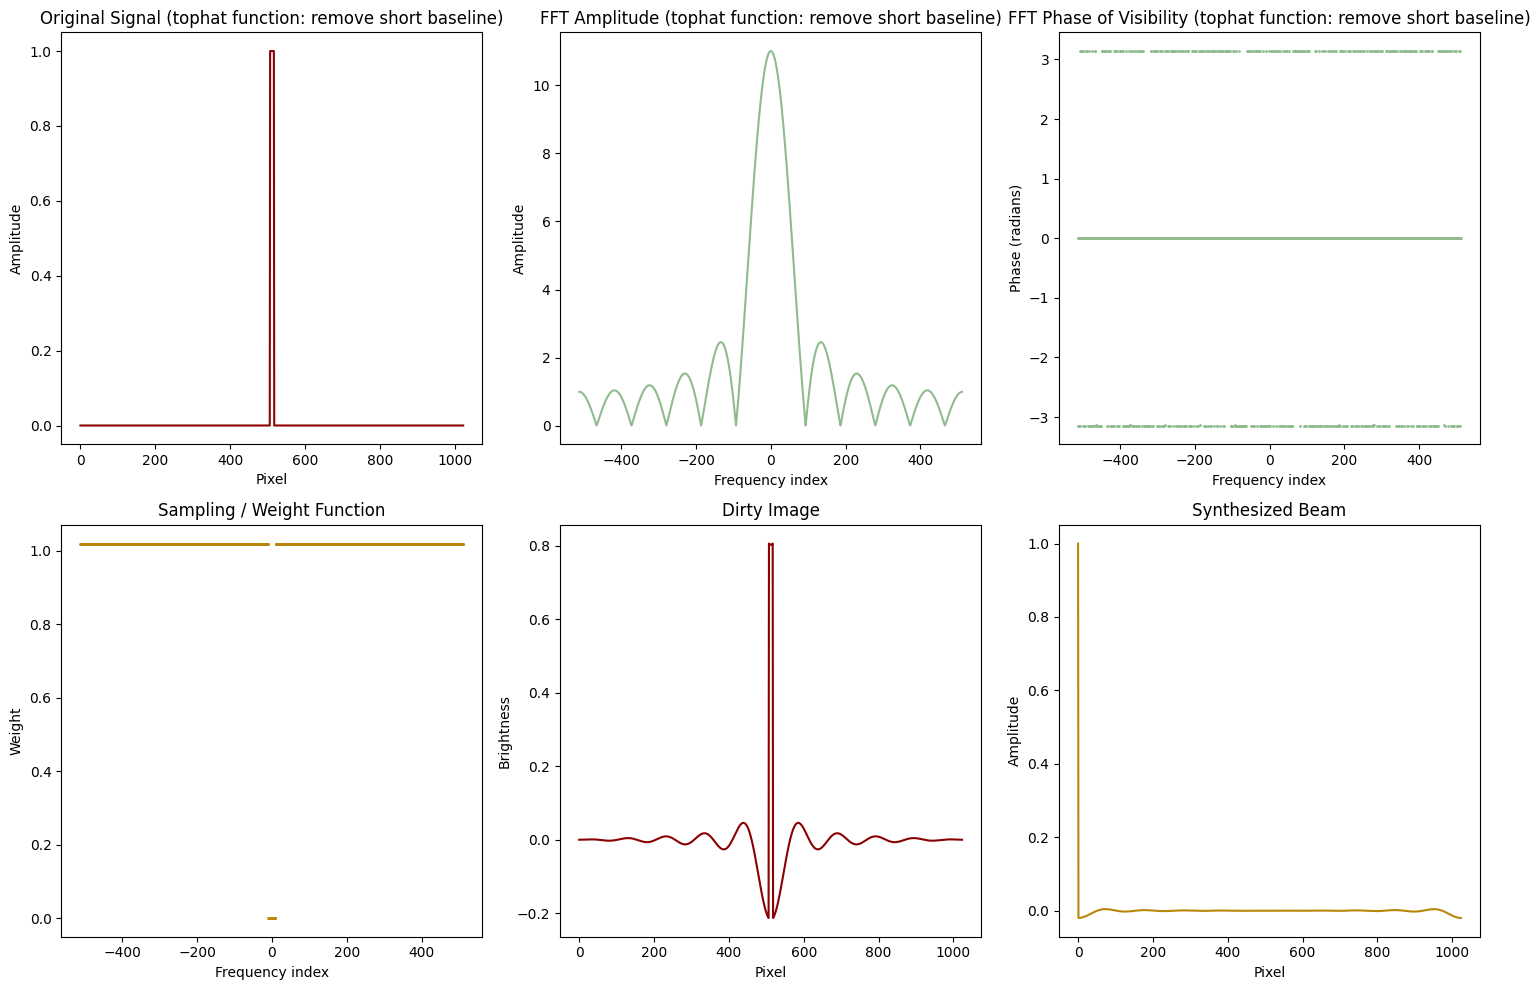

Peak amplitude of synthesized beam: 1.0
256


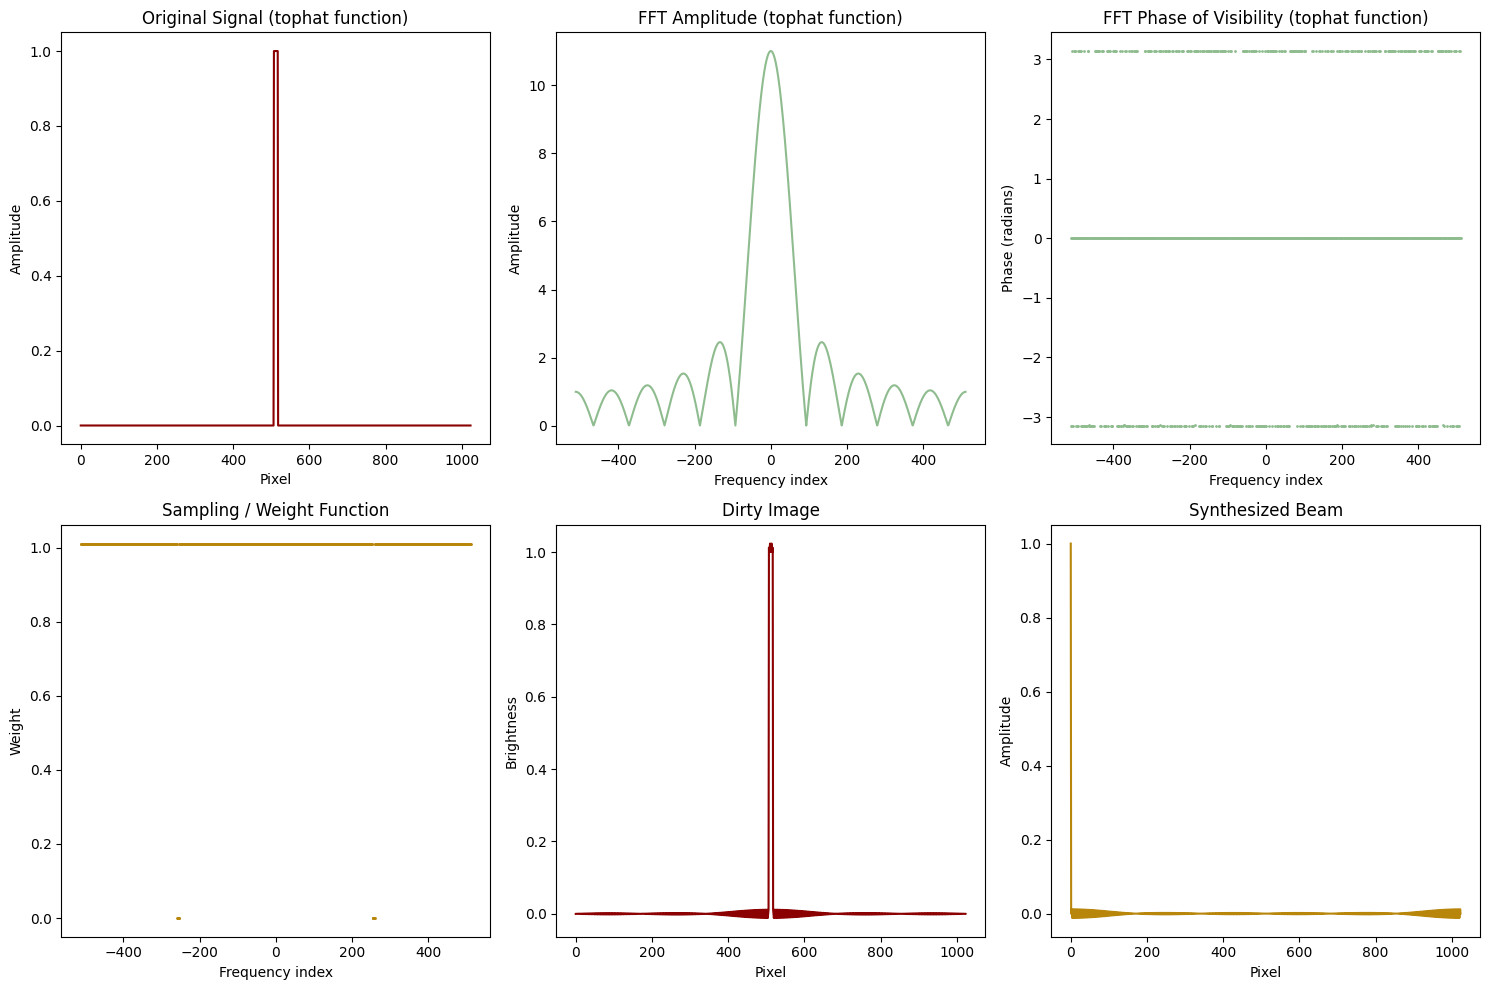

Peak amplitude of synthesized beam: 1.0


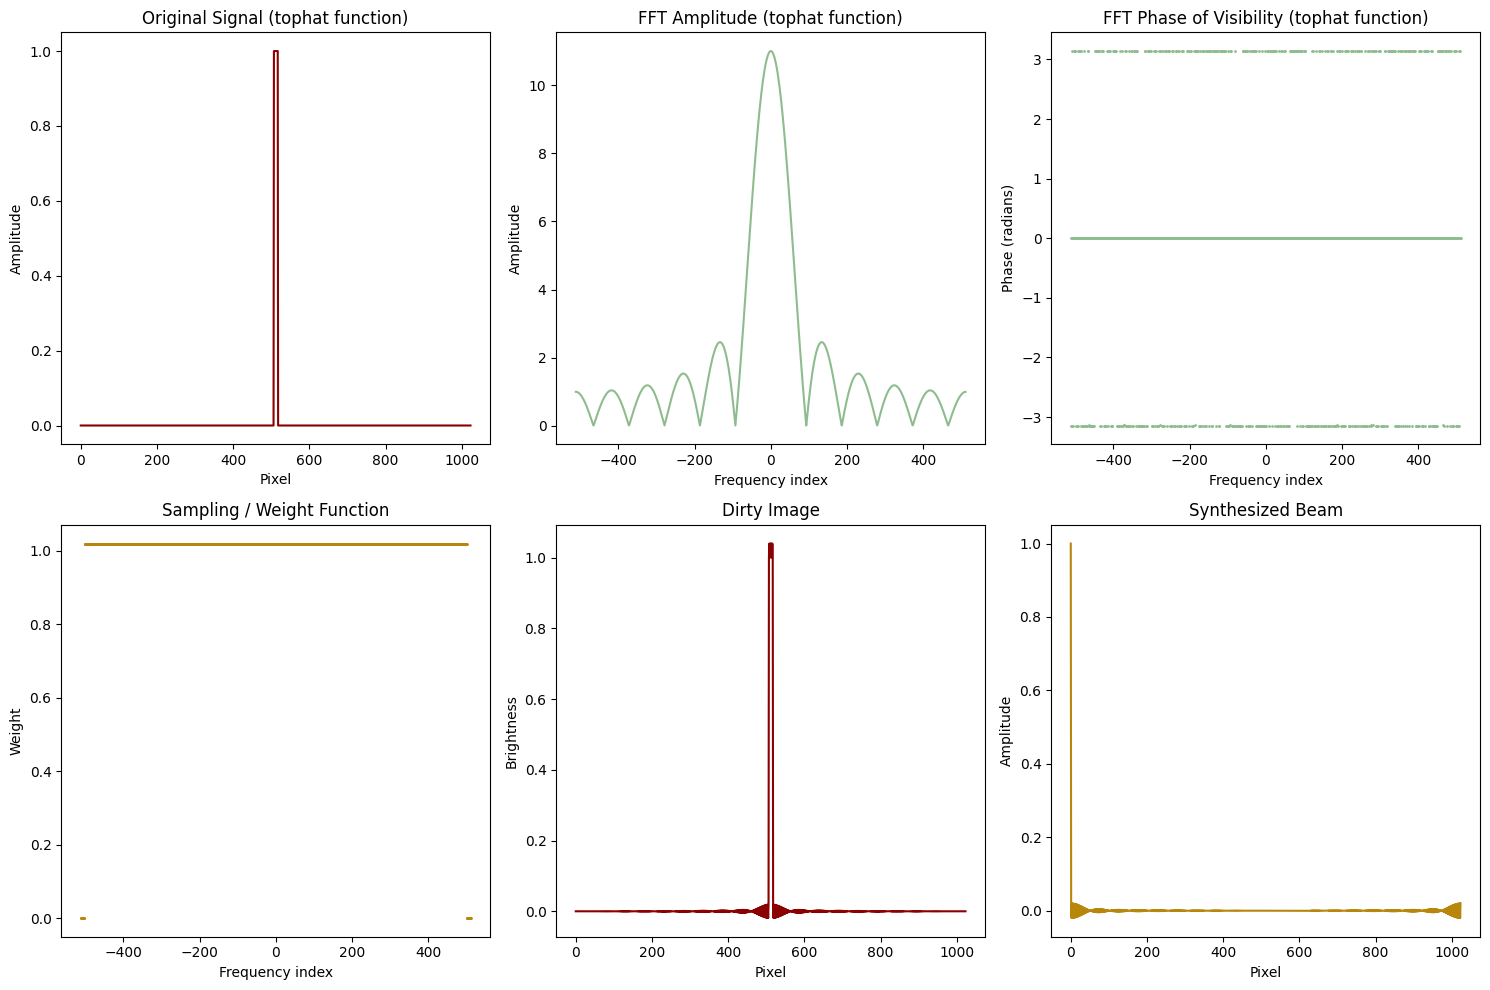

Peak amplitude of synthesized beam: 1.0


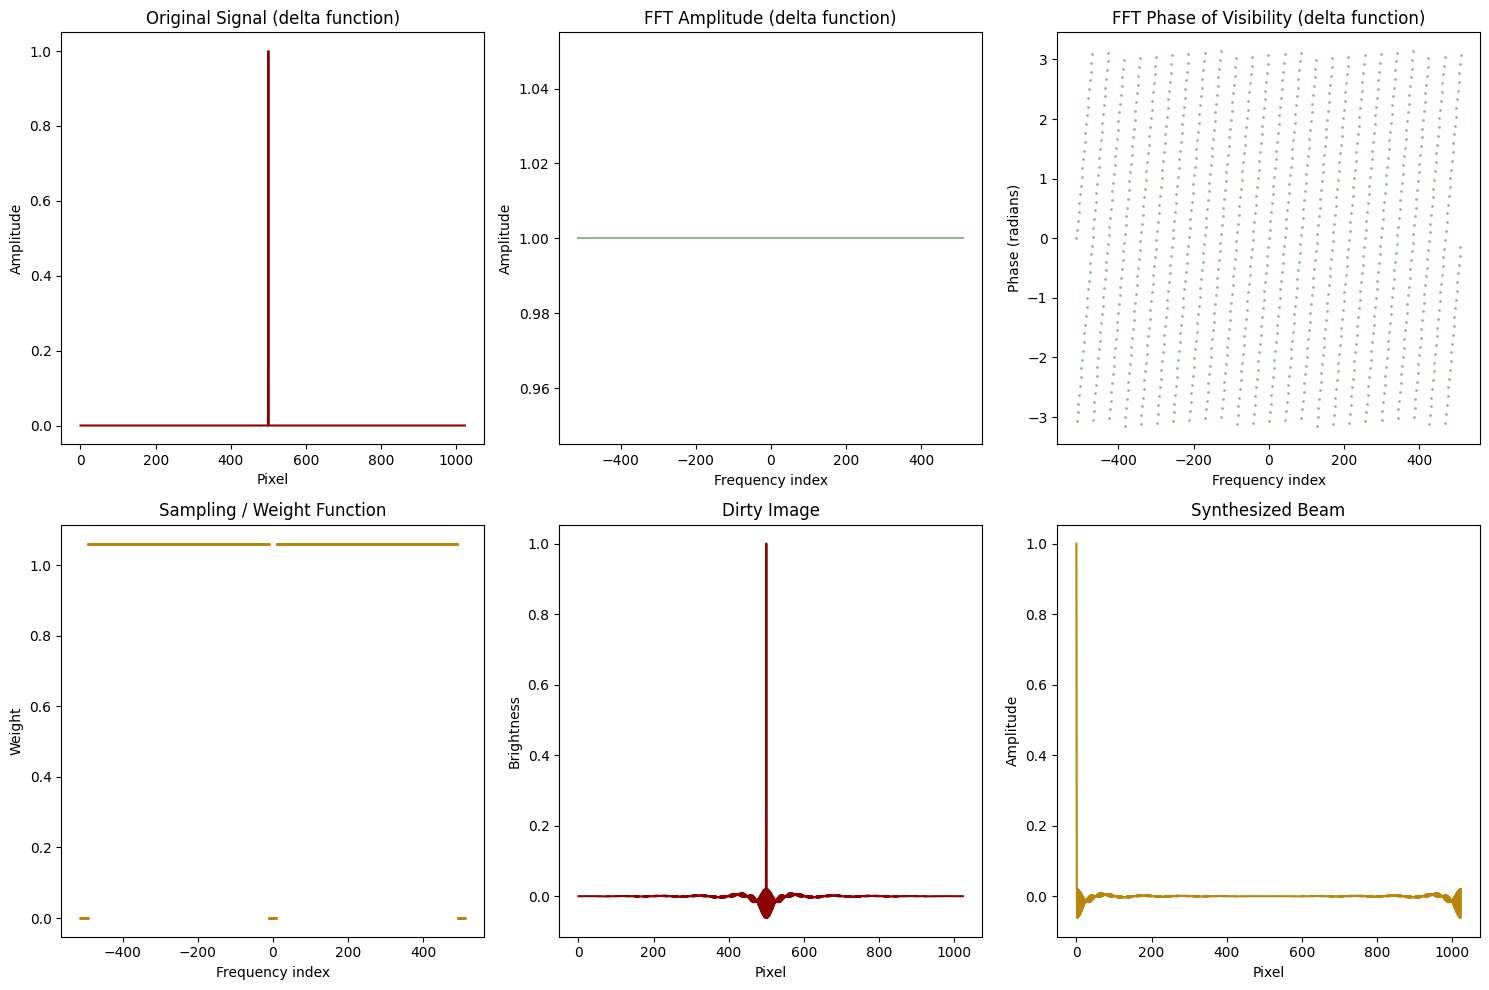

Peak amplitude of synthesized beam: 1.0


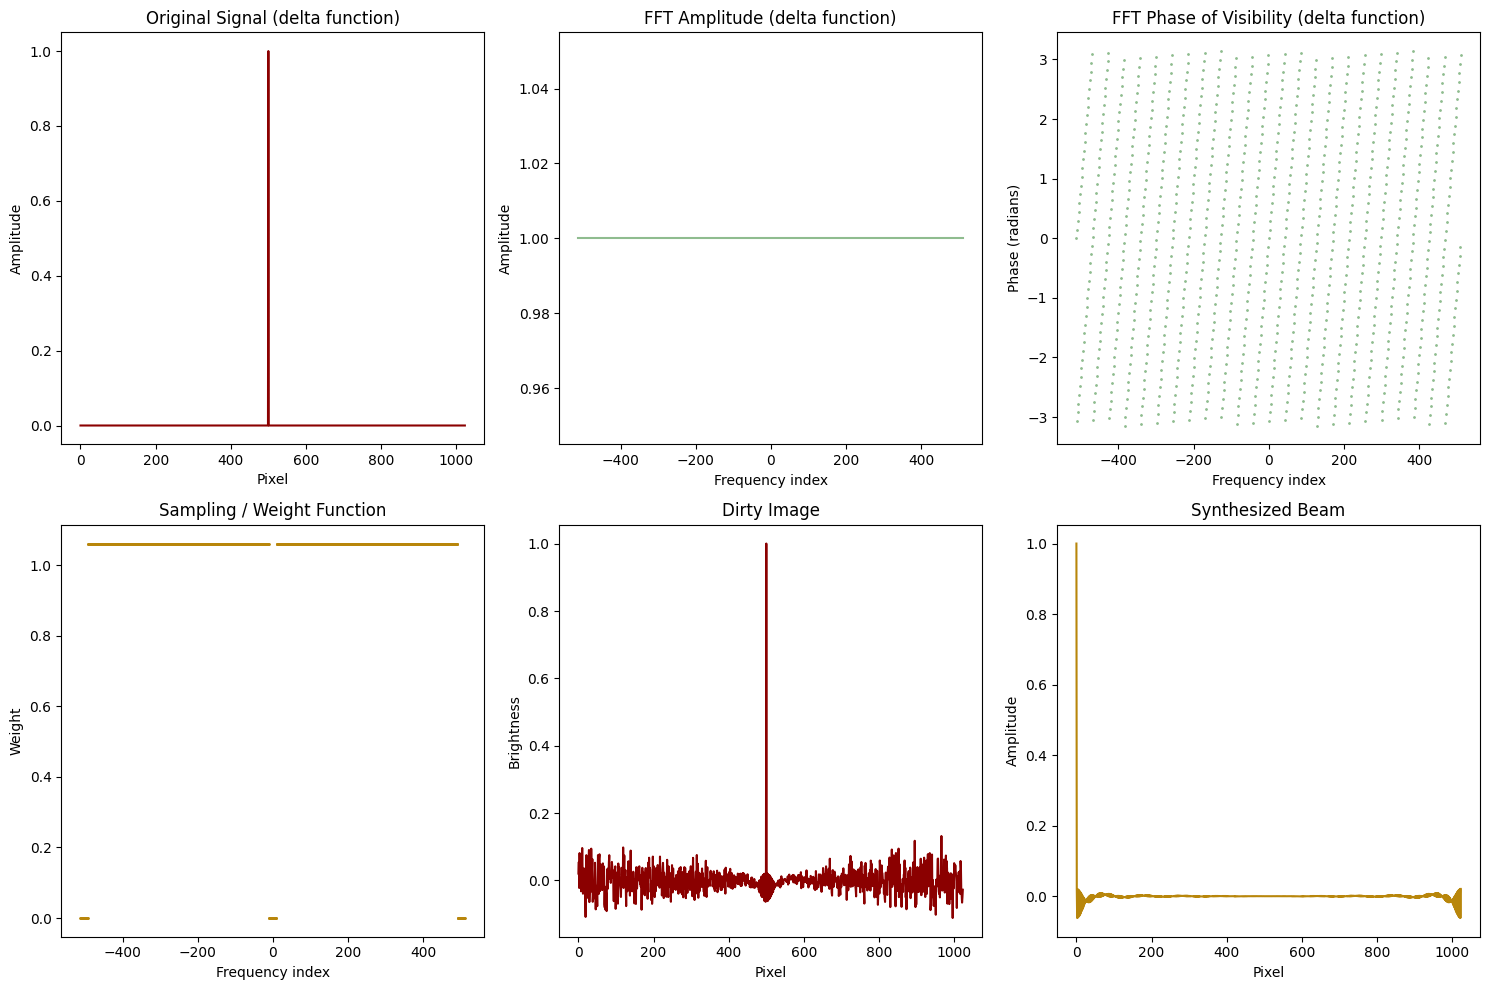

Peak amplitude of synthesized beam: 1.0


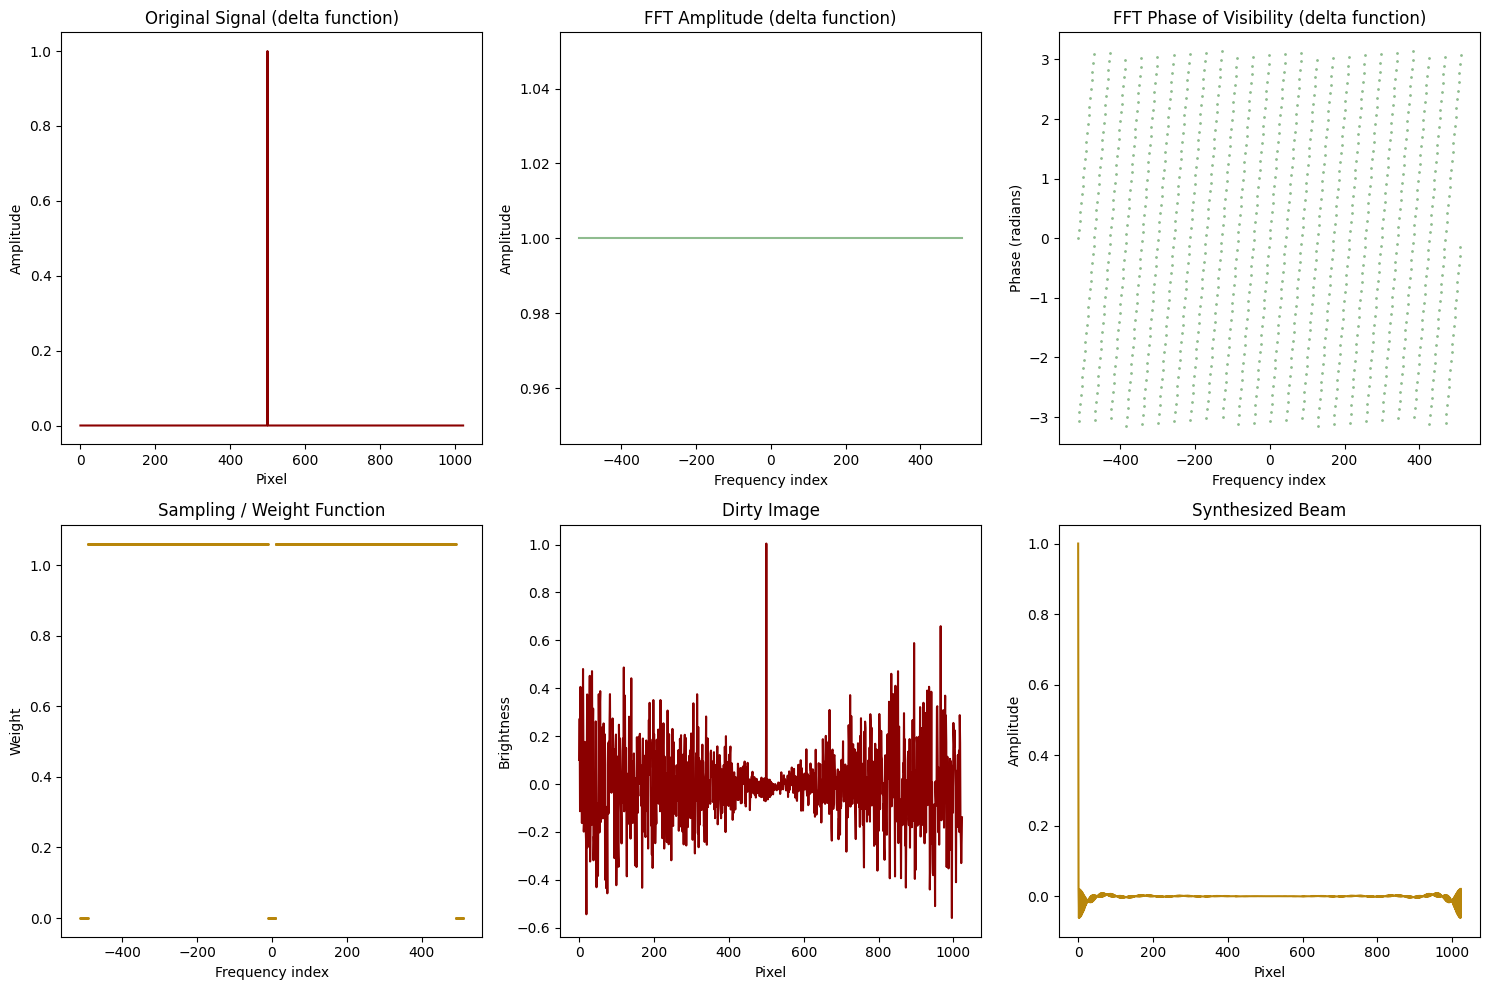

Peak amplitude of synthesized beam: 1.0


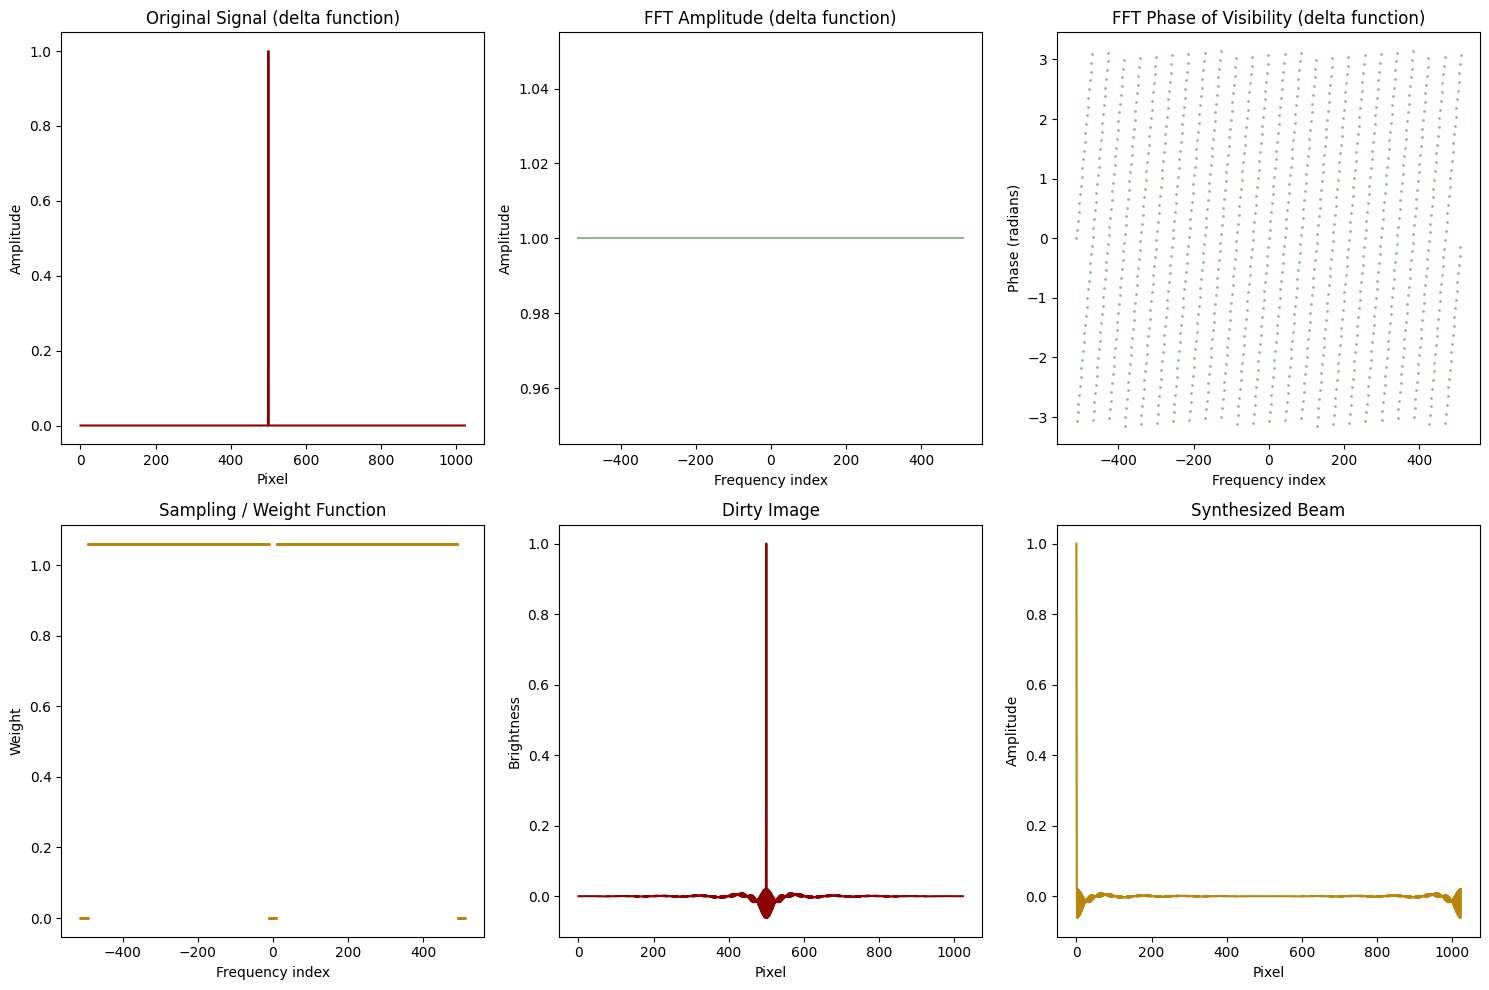

Peak amplitude of synthesized beam: 1.0


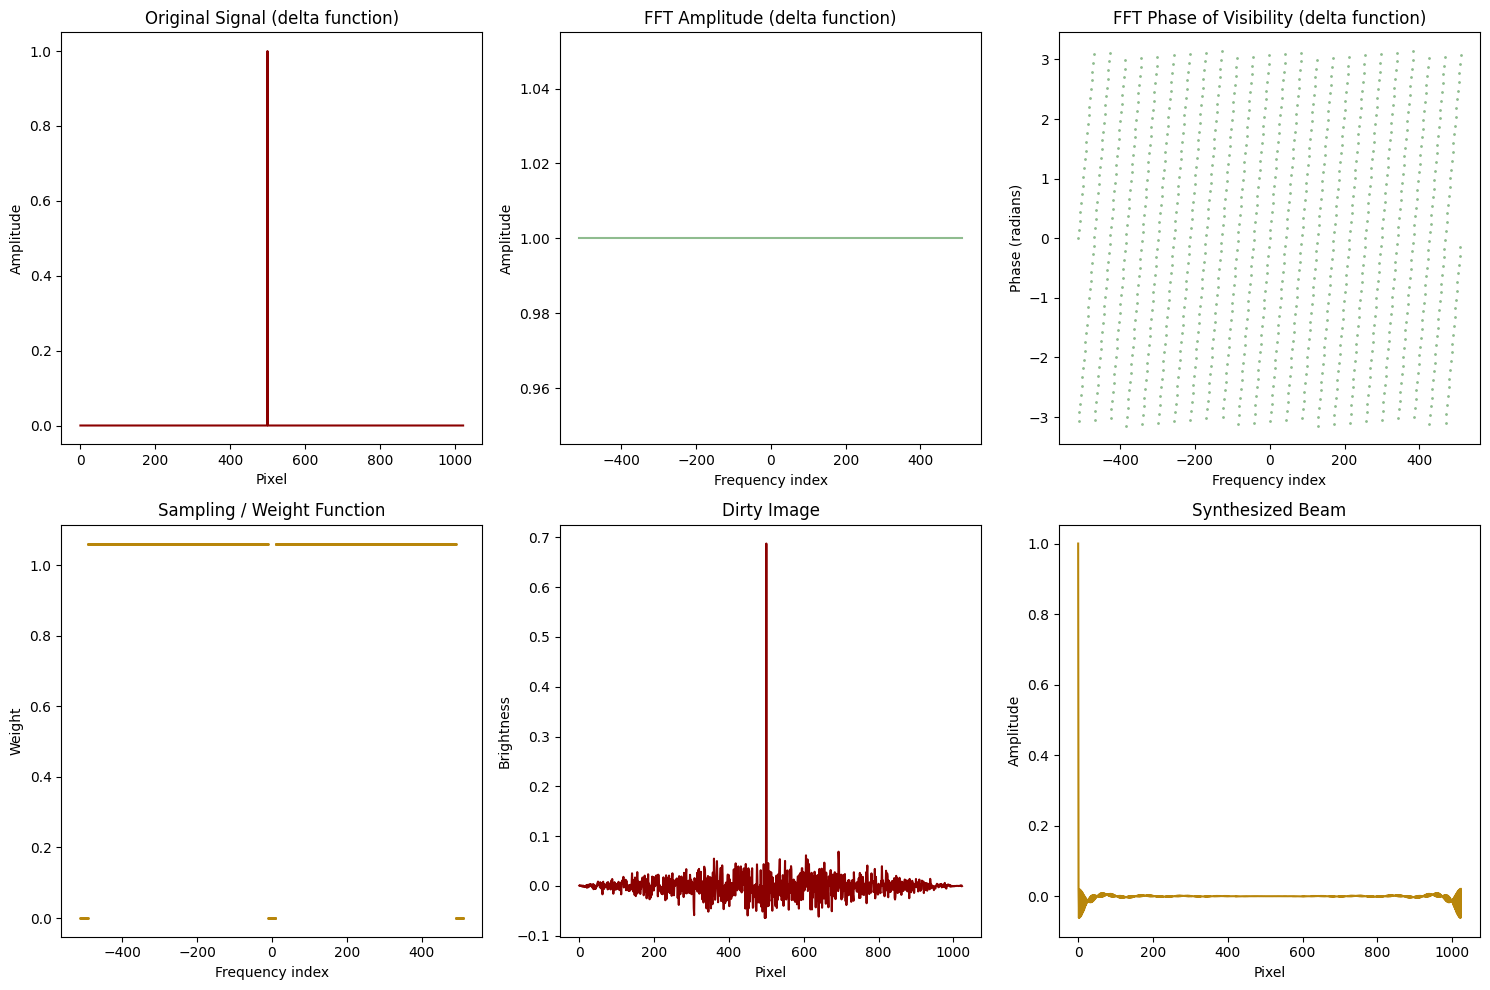

Peak amplitude of synthesized beam: 1.0


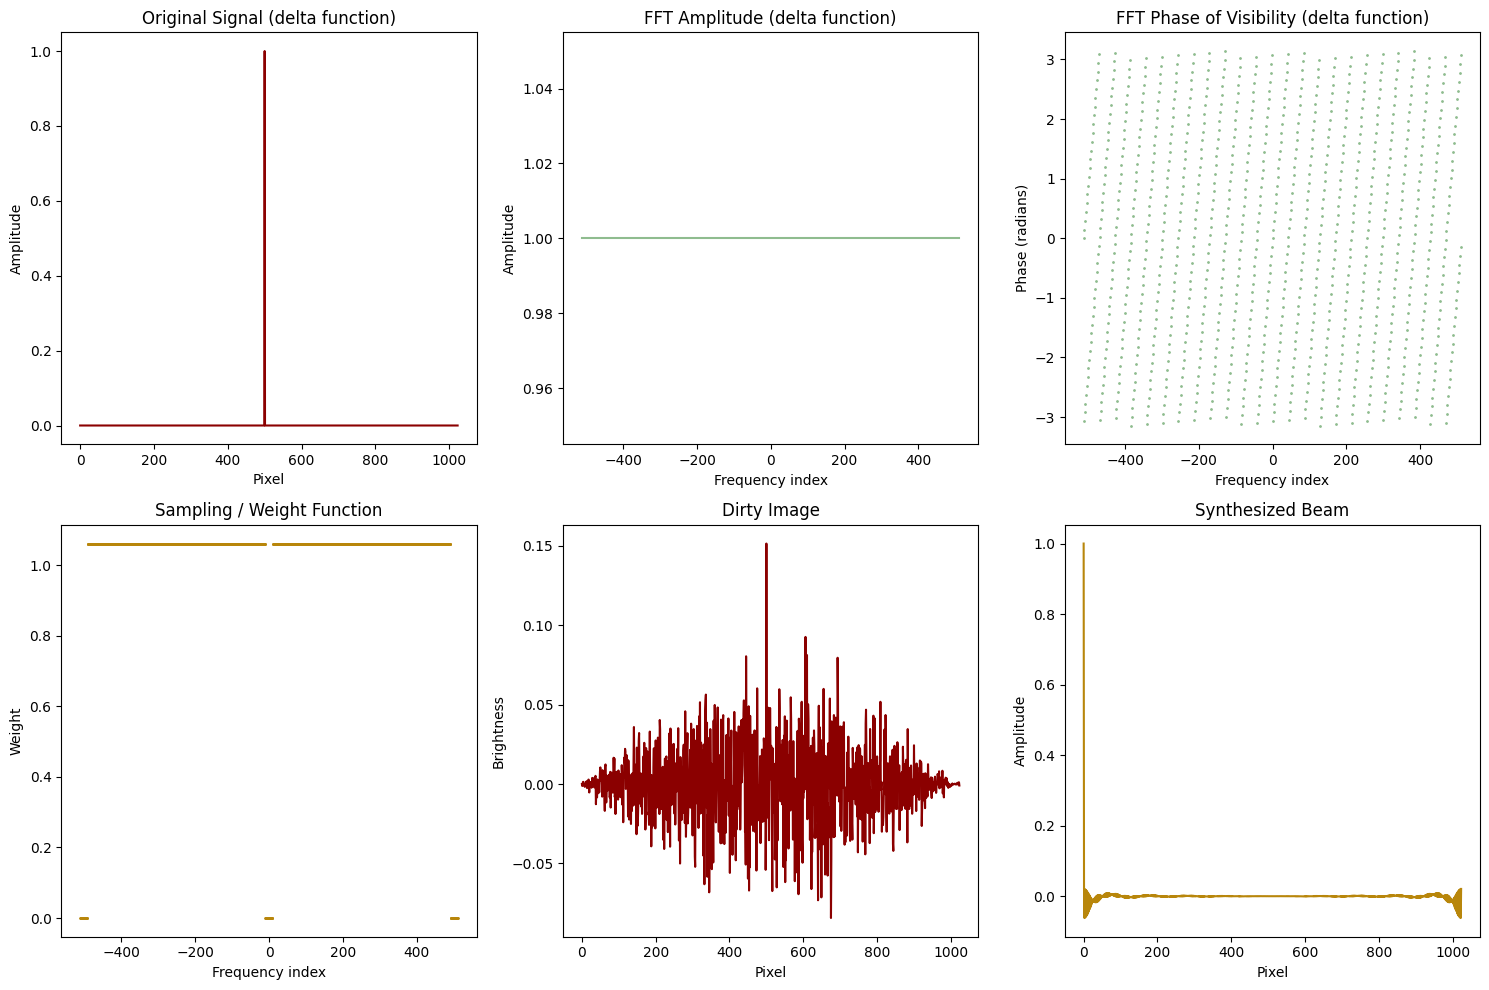

Peak amplitude of synthesized beam: 1.0


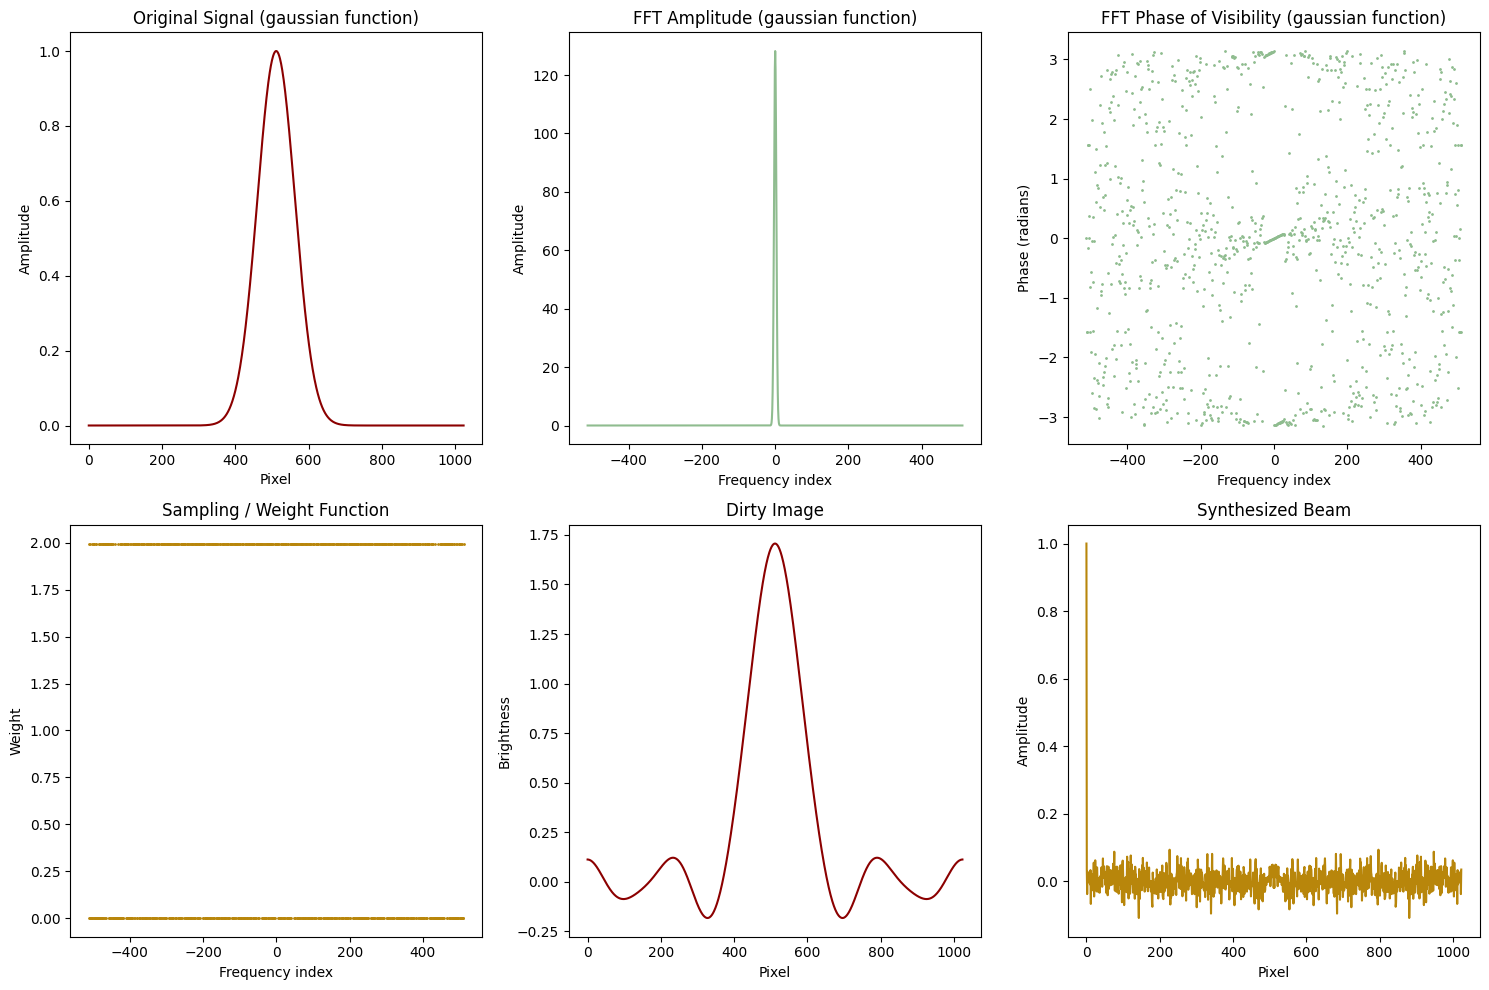

Peak amplitude of synthesized beam: 1.0


In [6]:

def radio_simulation(case='delta', title='', N=1024, missing_fraction=0.5, mode='no-weight', noise_std=0, phase_error_width=0):
    """
    Perform radio simulation for different cases and weighting schemes.

    Parameters:
        case (str): The sky model ('delta', 'sine', 'tophat').
        N (int): Size of the array.
        missing_fraction (float): Fraction of baselines to remove.
        mode (str): Weighting mode ('random', 'long', 'short', 'mid').
        noise_std (float): Standard deviation of Gaussian noise to add to visibilities.
        phase_error_width (float): Width of phase error distribution (radians).
    """
    # Create the sky model
    if case == 'delta':
        sky = np.zeros(N)
        sky[500] = 1  # Delta function at the center
    elif case == 'sine':
        freq = 50  # Frequency in cycles across the array
        x = np.arange(N)
        sky = np.sin(2/3 * np.pi * freq * x / (N*2))  # Sine wave
    elif case == 'tophat':
        sky = np.zeros(N)
        sky[N//2-5:N//2+1+5] = 1  # Top-hat function (boxcar)
        #sky[N//4:2*N//4] = 1  # Top-hat function (boxcar)
    elif case == 'gaussian':
        x = np.linspace(-5, 5, N)
        sky = np.exp(-x**2 / (2 * 0.5**2)) 
    else:
        raise ValueError("Invalid case. Choose from 'delta', 'sine', or 'tophat'.")

    vis = fft(sky)
    vis_shifted = fftshift(vis)
    amp = np.abs(vis_shifted)
    phase = np.angle(vis_shifted)
    freqs = fftshift(fftfreq(N, d=1/N))  

    # Create the weight function
    np.random.seed(42)
    weights = np.ones(N)
    if mode == 'random':
        missing = np.random.choice(N//2, size=int(missing_fraction * N/2), replace=False)
        weights[missing] = 0
        weights[-missing] = 0  # Ensure symmetry
    elif mode == 'long':
        weights[0:10] = 0 
        weights[N-10:N] = 0  # Remove long baselines
    elif mode == 'no-weight':
        weights = np.ones(N)
    elif mode == 'short':
        mid_point = N // 2  # Middle of the array
        offset = 10  # Number of baselines to remove around the mid-point
        weights[mid_point - offset:mid_point + offset] = 0  # Remove mid baselines symmetrically
    elif mode == 'mid':
        mid_index = N // 2  # index of 0

        half_mid = mid_index // 2  # midpoint of negative side
        print(half_mid)
        weights[half_mid-3: half_mid+3] = 0      # remove middle of negative side

        sym_half_mid = N - half_mid + 1  # symmetric index on positive side
        weights[sym_half_mid -3: sym_half_mid+3] = 0       # remove middle of positive side
    elif mode == 'short_long':
        weights[0:20] = 0 
        weights[N-20:N] = 0  # Remove long baselines

        mid_point = N // 2  # Middle of the array
        offset = 10  # Number of baselines to remove around the mid-point
        weights[mid_point - offset:mid_point + offset] = 0  
        
    else:
        raise ValueError("Invalid mode. Choose from 'random', 'long', 'short', or 'mid'.")

    # Normalize weights
    weights *= N / np.sum(weights)

    # Perform FFT and apply weights
    vis = fft(sky)
    vis_shifted = fftshift(vis)

    # Add noise to visibilities
    if noise_std > 0:
        noise_real = np.random.normal(0, noise_std, len(vis_shifted))
        noise_imag = np.random.normal(0, noise_std, len(vis_shifted))
        noise = noise_real + 1j * noise_imag
        noise[len(vis_shifted)//2:] = np.conj(noise[:len(vis_shifted)//2][::-1])  # Ensure Hermitian symmetry
        vis_shifted += noise

    # Add phase errors to visibilities
    if phase_error_width > 0:
        phase_errors = np.random.uniform(-phase_error_width, phase_error_width, len(vis_shifted))
        phase_errors[len(vis_shifted)//2:] = -phase_errors[:len(vis_shifted)//2][::-1]  # Ensure Hermitian symmetry
        vis_shifted *= np.exp(1j * phase_errors)

    vis_weighted = vis_shifted * weights

    # Create the dirty image
    dirty_image = np.real(ifft(ifftshift(vis_weighted)))

    # Create the synthesized beam
    beam = np.real(ifft(ifftshift(weights)))

    # Create a single figure with 6 subplots
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))

    # Plot the original signal
    axs[0, 0].plot( sky, color='darkred')
    axs[0, 0].set_title(f'Original Signal ({title})')
    axs[0, 0].set_xlabel('Pixel')
    axs[0, 0].set_ylabel('Amplitude')

    # Plot FFT amplitude
    axs[0, 1].plot(freqs, amp, color='darkseagreen')
    axs[0, 1].set_title(f'FFT Amplitude ({title})')
    axs[0, 1].set_xlabel('Frequency index')
    axs[0, 1].set_ylabel('Amplitude')

    # Plot FFT phase
    #axs[0, 2].plot(phase)
    axs[0, 2].scatter(freqs, phase, s=1, color='darkseagreen')
    axs[0, 2].set_title(f'FFT Phase of Visibility ({title})')
    axs[0, 2].set_xlabel('Frequency index')
    axs[0, 2].set_ylabel('Phase (radians)')

    # Plot the weight function
    #axs[1, 0].plot(weights)
    axs[1, 0].scatter(freqs, weights, s=1, color='darkgoldenrod')
    axs[1, 0].set_title('Sampling / Weight Function')
    axs[1, 0].set_xlabel('Frequency index')
    axs[1, 0].set_ylabel('Weight')

    # Plot the dirty image
    axs[1, 1].plot(dirty_image, color='darkred')
    axs[1, 1].set_title('Dirty Image')
    axs[1, 1].set_xlabel('Pixel')
    axs[1, 1].set_ylabel('Brightness')

    # Plot the synthesized beam
    axs[1, 2].plot(beam, color='darkgoldenrod')
    axs[1, 2].set_title('Synthesized Beam')
    axs[1, 2].set_xlabel('Pixel')
    axs[1, 2].set_ylabel('Amplitude')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

    print(f'Peak amplitude of synthesized beam: {np.max(beam)}')

# Example usage
# Case 1: function with random weighting
radio_simulation(case='delta', title= 'tophat function: remove long baseline', mode='long')
radio_simulation(case='tophat', title= 'tophat function: remove short baseline', mode='short')
radio_simulation(case='tophat', title= 'tophat function', mode='mid')
radio_simulation(case='tophat', title= 'tophat function', mode='long')

# Case 2: function with random weighting and no noise
radio_simulation(case='delta', title='delta function', mode='short_long', noise_std=0, phase_error_width=0)
radio_simulation(case='delta', title='delta function', mode='short_long', noise_std=1, phase_error_width=0)
radio_simulation(case='delta', title='delta function', mode='short_long', noise_std=5, phase_error_width=0)

# Case 3: function with weighting and phase errors
radio_simulation(case='delta', title='delta function', mode='short_long', noise_std=0, phase_error_width=np.radians(0))
radio_simulation(case='delta', title='delta function', mode='short_long', noise_std=0, phase_error_width=np.radians(80))
radio_simulation(case='delta', title='delta function', mode='short_long', noise_std=0, phase_error_width=np.radians(150))

# Case 4: Gaussian function
radio_simulation(case='gaussian', title='gaussian function', mode='random')